# TP3 - Detección de logo

Se busca detectar el logo de Coca-Cola usando el template pattern.png

Primero se prueba una detección por imagen, luego múltiples detecciones en coca_multi.png y finalmente se aplica el mismo algoritmo a todas las imágenes

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 6)

In [19]:
ruta_imagenes = Path("images")
ruta_template = Path("template/pattern.png")
template = cv2.imread(str(ruta_template))
imagenes = sorted(list(ruta_imagenes.glob("*")))

In [20]:
template = cv2.imread(str(ruta_template))
imagenes = sorted(list(ruta_imagenes.glob("*")))

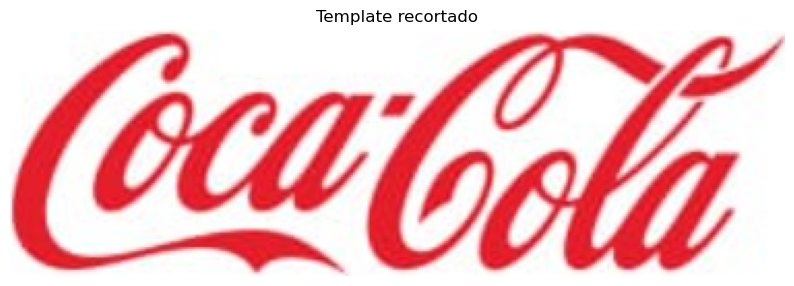

Tamaño: (119, 375, 3)


In [21]:
def recortar_template(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    mask = gray < 245
    ys, xs = np.where(mask)

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    return img[y1:y2, x1:x2]
template_recortado = recortar_template(template)

plt.imshow(cv2.cvtColor(template_recortado, cv2.COLOR_BGR2RGB))
plt.title("Template recortado")
plt.axis("off")
plt.show()

print("Tamaño:", template_recortado.shape)

In [22]:
def crear_detector():
    try:
        detector = cv2.SIFT_create()
        matcher = cv2.BFMatcher(cv2.NORM_L2)
        nombre = "SIFT"
    except:
        detector = cv2.ORB_create(nfeatures=4000)
        matcher = cv2.BFMatcher(cv2.NORM_HAMMING)
        nombre = "ORB"
    return detector, matcher, nombre

detector, matcher, nombre_detector = crear_detector()
print("Detector usado:", nombre_detector)

Detector usado: SIFT


In [23]:
def a_gris(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


def dibujar_cajas(img, detecciones):
    salida = img.copy()

    for box, score in detecciones:
        x1, y1, x2, y2 = box

        cv2.rectangle(salida, (x1, y1), (x2, y2), (0, 255, 0), 2)

        cv2.putText(
            salida,
            f"{score:.2f}",
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

    return salida

In [24]:
def detectar_logo(img, template_img, ratio=0.78, min_matches=6):
    img_gray = a_gris(img)
    temp_gray = a_gris(template_img)

    versiones_template = [
        temp_gray,
        255 - temp_gray
    ]

    mejor = None
    mejor_score = 0
    mejor_info = None

    for temp in versiones_template:
        kp_t, des_t = detector.detectAndCompute(temp, None)
        kp_i, des_i = detector.detectAndCompute(img_gray, None)

        if des_t is None or des_i is None:
            continue

        matches = matcher.knnMatch(des_t, des_i, k=2)
        buenos = []
        for par in matches:
            if len(par) < 2:
                continue

            m, n = par

            if m.distance < ratio * n.distance:
                buenos.append(m)

        if len(buenos) < min_matches:
            continue

        src_pts = np.float32([kp_t[m.queryIdx].pt for m in buenos]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp_i[m.trainIdx].pt for m in buenos]).reshape(-1, 1, 2)

        H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        if H is None:
            continue

        inliers = int(mask.sum())
        score = inliers / len(buenos)

        h, w = temp.shape

        esquinas = np.float32([
            [0, 0],
            [w, 0],
            [w, h],
            [0, h]
        ]).reshape(-1, 1, 2)
        proyectadas = cv2.perspectiveTransform(esquinas, H)

        xs = proyectadas[:, 0, 0]
        ys = proyectadas[:, 0, 1]
        x1 = int(max(0, xs.min()))
        y1 = int(max(0, ys.min()))
        x2 = int(min(img.shape[1], xs.max()))
        y2 = int(min(img.shape[0], ys.max()))

        ancho = x2 - x1
        alto = y2 - y1

        if ancho <= 20 or alto <= 10:
            continue
        if score > mejor_score:
            mejor_score = score
            mejor = ((x1, y1, x2, y2), score)
            mejor_info = {
                "matches": len(buenos),
                "inliers": inliers
            }
    return mejor, mejor_info

COCA-COLA-LOGO.jpg
  box: (52, 482, 1291, 862)
  confianza: 0.407
  matches: 27
  inliers: 11
--------------------------------------------------


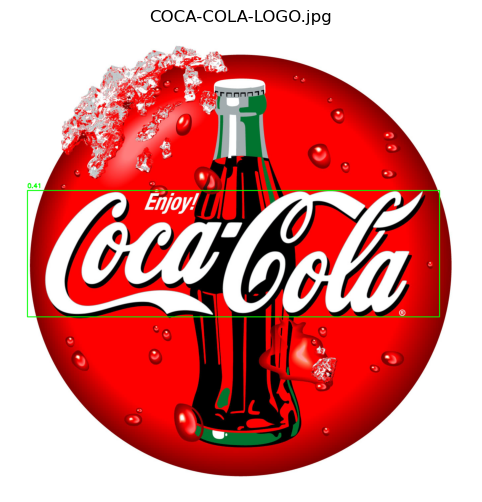

coca_logo_1.png
  box: (35, 208, 195, 261)
  confianza: 0.73
  matches: 37
  inliers: 27
--------------------------------------------------


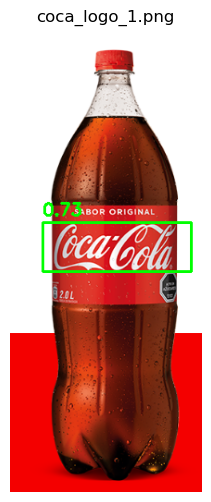

coca_logo_2.png
  box: (0, 125, 233, 209)
  confianza: 0.69
  matches: 29
  inliers: 20
--------------------------------------------------


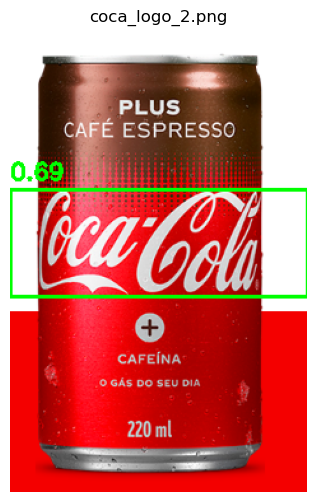

coca_multi.png
  No se detectó logo
--------------------------------------------------


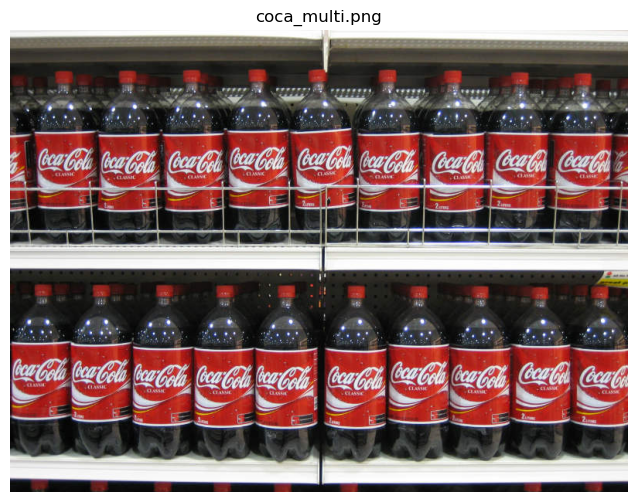

coca_retro_1.png
  box: (113, 116, 624, 266)
  confianza: 0.739
  matches: 23
  inliers: 17
--------------------------------------------------


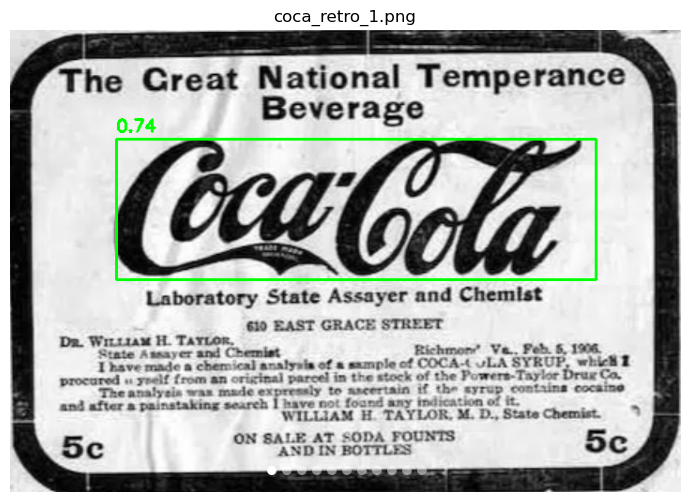

coca_retro_2.png
  box: (61, 196, 213, 239)
  confianza: 0.758
  matches: 33
  inliers: 25
--------------------------------------------------


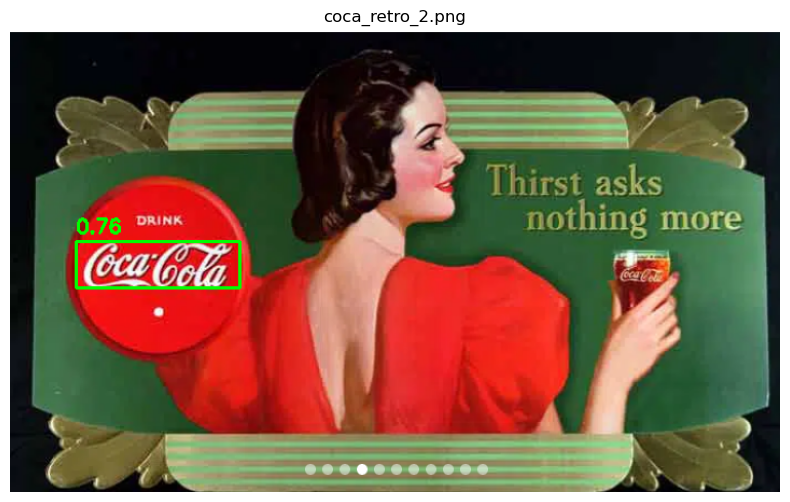

logo_1.png
  box: (204, 209, 489, 302)
  confianza: 0.767
  matches: 30
  inliers: 23
--------------------------------------------------


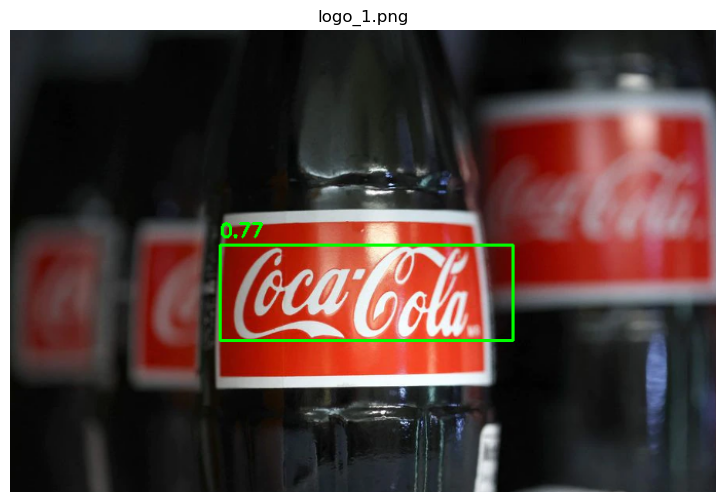

In [25]:
resultados_individuales = {}

for img_path in imagenes:
    img = cv2.imread(str(img_path))
    deteccion, info = detectar_logo(
        img,
        template_recortado,
        ratio=0.78,
        min_matches=6
    )

    detecciones = []
    if deteccion is not None:
        detecciones = [deteccion]

    resultados_individuales[img_path.name] = detecciones

    print(img_path.name)

    if deteccion is None:
        print("  No se detectó logo")
    else:
        box, score = deteccion
        print("  box:", box)
        print("  confianza:", round(score, 3))
        print("  matches:", info["matches"])
        print("  inliers:", info["inliers"])

    print("-" * 50)
    resultado = dibujar_cajas(img, detecciones)
    plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

In [26]:
def iou(box_a, box_b):
    xA = max(box_a[0], box_b[0])
    yA = max(box_a[1], box_b[1])
    xB = min(box_a[2], box_b[2])
    yB = min(box_a[3], box_b[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])

    return inter_area / (area_a + area_b - inter_area + 1e-6)
def nms(detecciones, iou_threshold=0.3):
    detecciones = sorted(detecciones, key=lambda x: x[1], reverse=True)
    finales = []

    while detecciones:
        mejor = detecciones.pop(0)
        finales.append(mejor)

        detecciones = [
            det for det in detecciones
            if iou(mejor[0], det[0]) < iou_threshold
        ]
    return finales

In [27]:
def detectar_varios_coca_multi(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    rojo_bajo1 = np.array([0, 50, 40])
    rojo_alto1 = np.array([15, 255, 255])

    rojo_bajo2 = np.array([160, 50, 40])
    rojo_alto2 = np.array([180, 255, 255])

    mask1 = cv2.inRange(hsv, rojo_bajo1, rojo_alto1)
    mask2 = cv2.inRange(hsv, rojo_bajo2, rojo_alto2)

    mask = cv2.bitwise_or(mask1, mask2)

    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    contornos, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    h_img, w_img = img.shape[:2]

    tapas = []

    for cnt in contornos:
        x, y, w, h = cv2.boundingRect(cnt)

        aspect = w / h
        if w < 12 or w > 70:
            continue

        if h < 10 or h > 45:
            continue

        if aspect < 0.7 or aspect > 3.5:
            continue

        fila_arriba = y < h_img * 0.16
        fila_abajo = (y > h_img * 0.47) and (y < h_img * 0.60)

        if not (fila_arriba or fila_abajo):
            continue

        tapas.append(((x, y, x + w, y + h), 0.8))

    tapas = nms(tapas, iou_threshold=0.1)

    detecciones = []

    for box_tapa, _ in tapas:
        x1, y1, x2, y2 = box_tapa

        cx = (x1 + x2) // 2

        label_w = 90
        label_h = 45

        label_x1 = int(cx - label_w // 2)
        label_y1 = int(y2 + 55)

        label_x2 = label_x1 + label_w
        label_y2 = label_y1 + label_h

        label_x1 = max(0, label_x1)
        label_y1 = max(0, label_y1)
        label_x2 = min(w_img, label_x2)
        label_y2 = min(h_img, label_y2)

        if (label_x2 - label_x1) < 50:
            continue

        if (label_y2 - label_y1) < 30:
            continue
        roi_mask = mask[label_y1:label_y2, label_x1:label_x2]
        if roi_mask.size == 0:
            continue
        red_ratio = np.count_nonzero(roi_mask) / roi_mask.size

        if red_ratio < 0.18:
            continue
        score = float(red_ratio)

        detecciones.append(((label_x1, label_y1, label_x2, label_y2), score))

    detecciones = nms(detecciones, iou_threshold=0.2)

    return detecciones, mask

Detecciones en coca_multi.png: 21
  box: (627, 408, 717, 453) confianza: 0.708
  box: (603, 138, 693, 183) confianza: 0.697
  box: (745, 133, 799, 178) confianza: 0.697
  box: (520, 134, 610, 179) confianza: 0.696
  box: (717, 410, 799, 455) confianza: 0.692
  box: (556, 408, 646, 453) confianza: 0.684
  box: (353, 128, 443, 173) confianza: 0.682
  box: (276, 131, 366, 176) confianza: 0.675
  box: (479, 408, 569, 453) confianza: 0.673
  box: (198, 134, 288, 179) confianza: 0.66
  box: (120, 136, 210, 181) confianza: 0.654
  box: (161, 409, 251, 454) confianza: 0.651
  box: (679, 134, 769, 179) confianza: 0.647
  box: (403, 407, 493, 452) confianza: 0.635
  box: (236, 404, 326, 449) confianza: 0.622
  box: (21, 398, 111, 443) confianza: 0.617
  box: (50, 129, 140, 174) confianza: 0.61
  box: (442, 128, 532, 173) confianza: 0.609
  box: (81, 402, 171, 447) confianza: 0.603
  box: (312, 403, 402, 448) confianza: 0.598
  box: (0, 128, 58, 173) confianza: 0.548


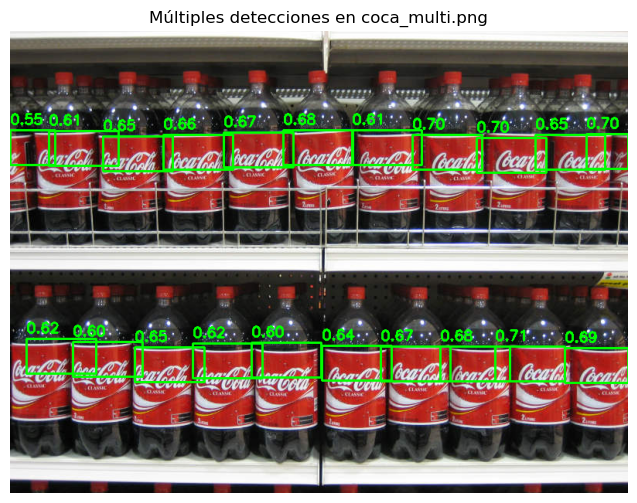

In [28]:
img_multi = cv2.imread(str(ruta_imagenes / "coca_multi.png"))

detecciones_multi, mask_multi = detectar_varios_coca_multi(img_multi)
print("Detecciones en coca_multi.png:", len(detecciones_multi))
for box, score in detecciones_multi:
    print("  box:", box, "confianza:", round(score, 3))

resultado_multi = dibujar_cajas(img_multi, detecciones_multi)

plt.imshow(cv2.cvtColor(resultado_multi, cv2.COLOR_BGR2RGB))
plt.title("Múltiples detecciones en coca_multi.png")
plt.axis("off")
plt.show()

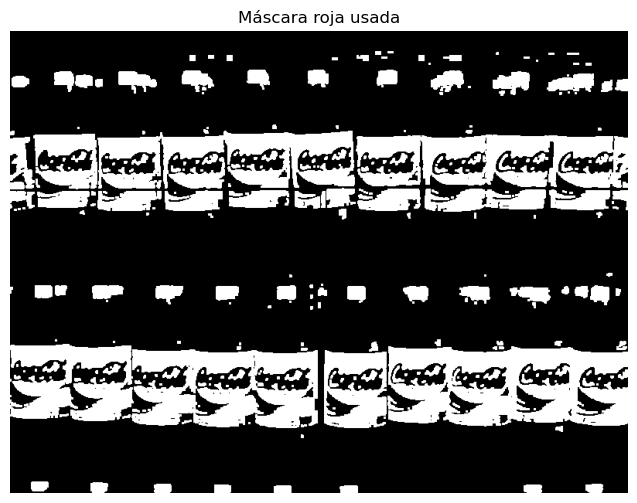

In [29]:
plt.imshow(mask_multi, cmap="gray")
plt.title("Máscara roja usada")
plt.axis("off")
plt.show()

COCA-COLA-LOGO.jpg
Detecciones: 1
  box: (52, 482, 1291, 862) confianza: 0.407
--------------------------------------------------


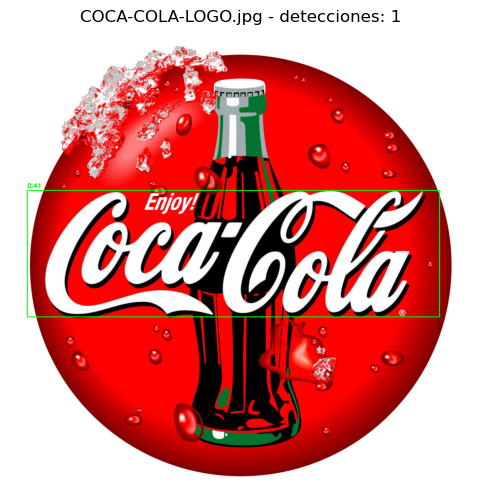

coca_logo_1.png
Detecciones: 1
  box: (35, 208, 195, 261) confianza: 0.73
--------------------------------------------------


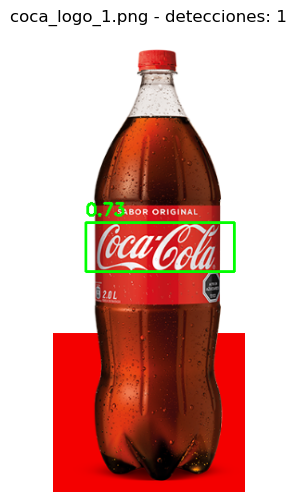

coca_logo_2.png
Detecciones: 1
  box: (0, 125, 233, 209) confianza: 0.69
--------------------------------------------------


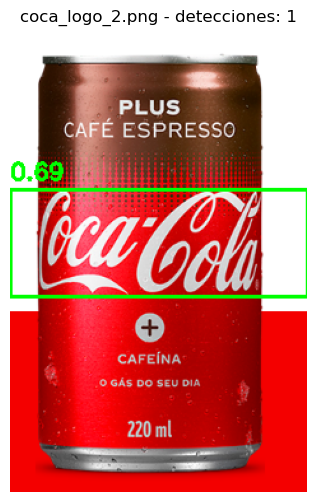

coca_multi.png
Detecciones: 21
  box: (627, 408, 717, 453) confianza: 0.708
  box: (603, 138, 693, 183) confianza: 0.697
  box: (745, 133, 799, 178) confianza: 0.697
  box: (520, 134, 610, 179) confianza: 0.696
  box: (717, 410, 799, 455) confianza: 0.692
  box: (556, 408, 646, 453) confianza: 0.684
  box: (353, 128, 443, 173) confianza: 0.682
  box: (276, 131, 366, 176) confianza: 0.675
  box: (479, 408, 569, 453) confianza: 0.673
  box: (198, 134, 288, 179) confianza: 0.66
  box: (120, 136, 210, 181) confianza: 0.654
  box: (161, 409, 251, 454) confianza: 0.651
  box: (679, 134, 769, 179) confianza: 0.647
  box: (403, 407, 493, 452) confianza: 0.635
  box: (236, 404, 326, 449) confianza: 0.622
  box: (21, 398, 111, 443) confianza: 0.617
  box: (50, 129, 140, 174) confianza: 0.61
  box: (442, 128, 532, 173) confianza: 0.609
  box: (81, 402, 171, 447) confianza: 0.603
  box: (312, 403, 402, 448) confianza: 0.598
  box: (0, 128, 58, 173) confianza: 0.548
--------------------------------

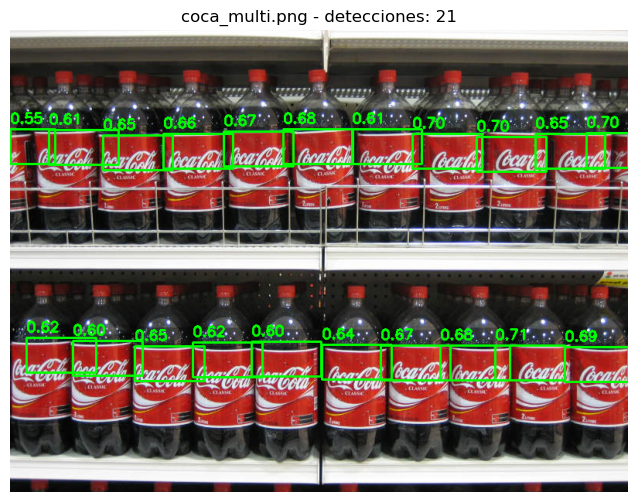

coca_retro_1.png
Detecciones: 1
  box: (113, 116, 624, 266) confianza: 0.739
--------------------------------------------------


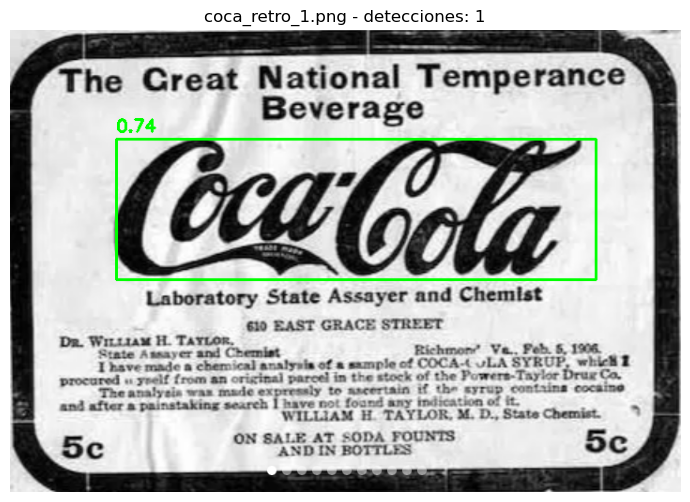

coca_retro_2.png
Detecciones: 1
  box: (61, 196, 213, 239) confianza: 0.758
--------------------------------------------------


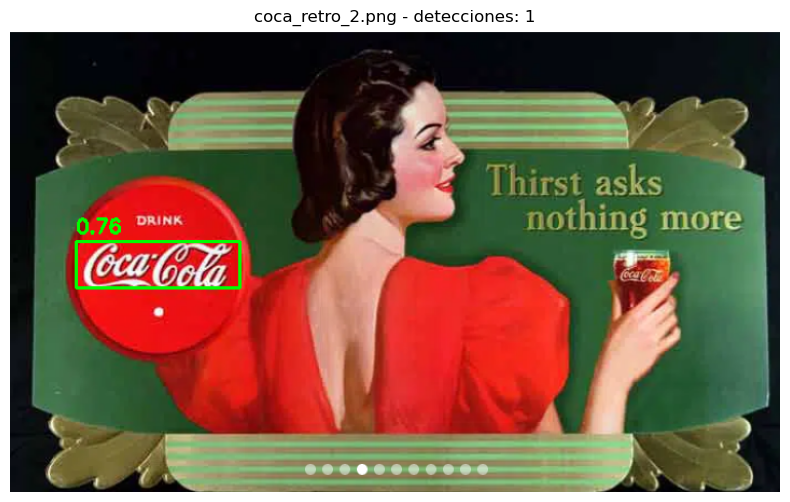

logo_1.png
Detecciones: 1
  box: (204, 209, 489, 302) confianza: 0.767
--------------------------------------------------


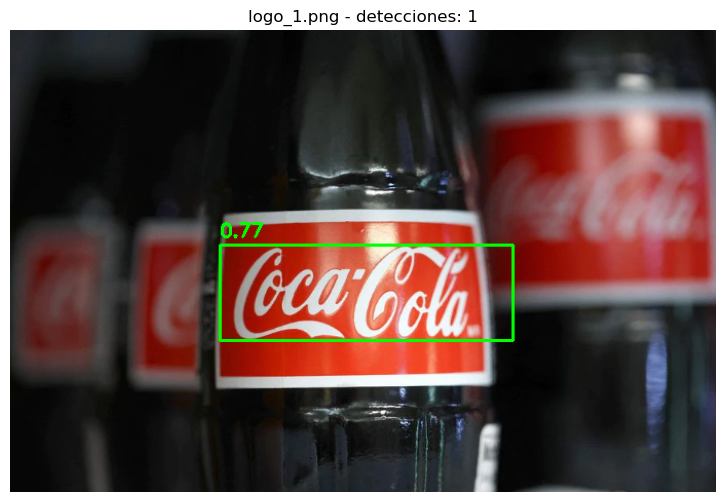

In [30]:
resultados_finales = {}

for img_path in imagenes:
    img = cv2.imread(str(img_path))
    if img_path.name == "coca_multi.png":
        detecciones, _ = detectar_varios_coca_multi(img)
    else:
        deteccion, info = detectar_logo(
            img,
            template_recortado,
            ratio=0.78,
            min_matches=6
        )

        detecciones = []

        if deteccion is not None:
            detecciones = [deteccion]

    resultados_finales[img_path.name] = detecciones

    print(img_path.name)
    print("Detecciones:", len(detecciones))

    for box, score in detecciones:
        print("  box:", box, "confianza:", round(score, 3))

    print("-" * 50)

    resultado = dibujar_cajas(img, detecciones)
    plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    plt.title(f"{img_path.name} - detecciones: {len(detecciones)}")
    plt.axis("off")
    plt.show()

Para las imágenes con un solo logo usé SIFT, porque el logo cambia de tamaño, color y apariencia entre las imágenes, con las correspondencias encontradas se calculó una homografía para ubicar la zona del logo

En coca_multi.png SIFT no funcionó bien porque hay muchas botellas iguales y las correspondencias se mezclaban entre distintos logos. Por eso usé una estrategia más simple para esa imagen: detectar las zonas rojas de las botellas y a partir de la posición de las tapas, estimar la zona donde está la etiqueta

La confianza en coca_multi.png no viene de un modelo entrenado, sino de la proporción de píxeles rojos dentro de la caja detectada por eso se toma como una medida aproximada

## Conclusión

El método con SIFT funcionó bien para detectar una instancia del logo en imágenes con cambios de escala y apariencia, para la imagen con varias botellas fue necesario usar otro criterio, porque las correspondencias se mezclaban entre objetos repetidos

Con esto se logró mostrar detecciones con cajas y un valor de confianza aproximado para cada caso